<a href="https://colab.research.google.com/github/itsdiego1012-source/Assignments/blob/PDI---Assignments/Pr%C3%A1ctica_8_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 8:** *Parte 1*
**Equipo 6:**
*   Castillo Díaz Ulises 	            2050354
*   González Garza Jorge Alberto	    2043501
*   Muñoz Baca Axel	                  2132103
*   Rodríguez Arreguín Diego Eduardo 	2004407

**Carga de librerías utilizadas**

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Carga de imagen**

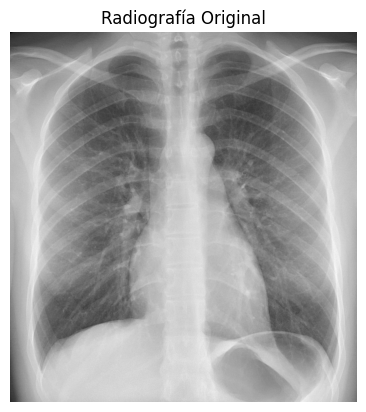

In [2]:
# Cargar la imagen médica original
img_org = 'XRAY.jpg'
img = cv.imread(img_org, cv.IMREAD_GRAYSCALE)

# Mostrar imagen en escala de grises
plt.imshow(img, cmap='gray')
plt.title('Radiografía Original')
plt.axis('off')
plt.show()

# **Ejercicio 1:** *Filtros de Suavizado*

In [3]:
# 1. Filtro de Media (Kernel 3x3) -> Suavizado ligero
blur_media = cv.blur(img, (3, 3))

# 2. Filtro Gaussiano (Kernel 5x5) -> Reducción de ruido gaussiano
blur_gauss = cv.GaussianBlur(img, (5, 5), 0)

# 3. Filtro de Mediana (Kernel 11x11) -> Suavizado agresivo (pérdida de textura fina)
blur_median = cv.medianBlur(img, 11)

**Comparación de filtros de suavizado**

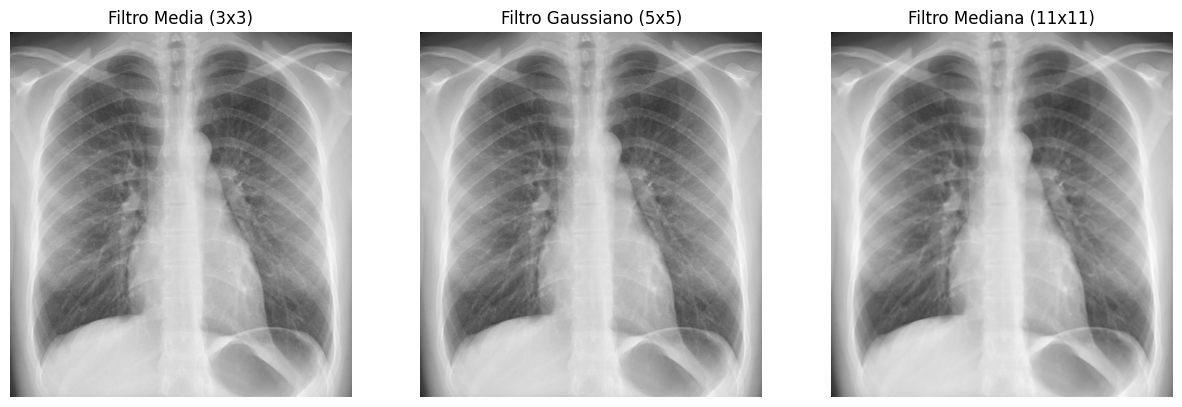

In [4]:
# Visualización de filtros de suavizado
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(blur_media, cmap='gray')
plt.title('Filtro Media (3x3)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blur_gauss, cmap='gray')
plt.title('Filtro Gaussiano (5x5)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blur_median, cmap='gray')
plt.title('Filtro Mediana (11x11)')
plt.axis('off')

plt.show()

## **Ejercicio 2:** *Detección de Bordes*

In [5]:
# 1. Sobel en X y Y
sobelx = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
# Combinar magnitud
sobel_combined = cv.magnitude(sobelx, sobely)

# 2. Laplaciano
laplacian = cv.Laplacian(img, cv.CV_64F, None, 5)
laplacian_abs = cv.convertScaleAbs(laplacian)

# 3. Filtro Kirsch (Dirección Norte - Manual)
# Máscara para detectar bordes horizontales superiores
kernel_kirsch_n = np.array([[ 5,  5,  5],
                            [-3,  0, -3],
                            [-3, -3, -3]])

kirsch_n = cv.filter2D(img, -1, kernel_kirsch_n)

**Comparación de filtros de detección de bordes**

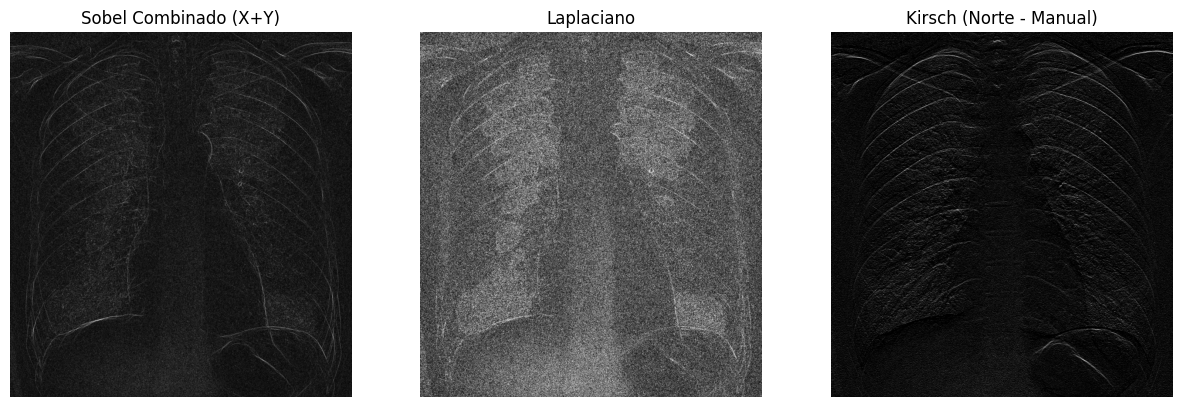

In [6]:
# Visualización de detección de bordes
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combinado (X+Y)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(kirsch_n, cmap='gray')
plt.title('Kirsch (Norte - Manual)')
plt.axis('off')

plt.show()

# **Ejercicio 3:** *Máscara Personalizada (Realce)*

In [7]:
# Máscara de afilado (Sharpening) para aumento de contraste en bordes locales
kernel_custom = np.array([[ 1, -5,  1],
                          [-5,  17, -5],
                          [ 1, -5,  1]])

img_custom = cv.filter2D(img, -1, kernel_custom)

**Comparación de realce con imágen original**

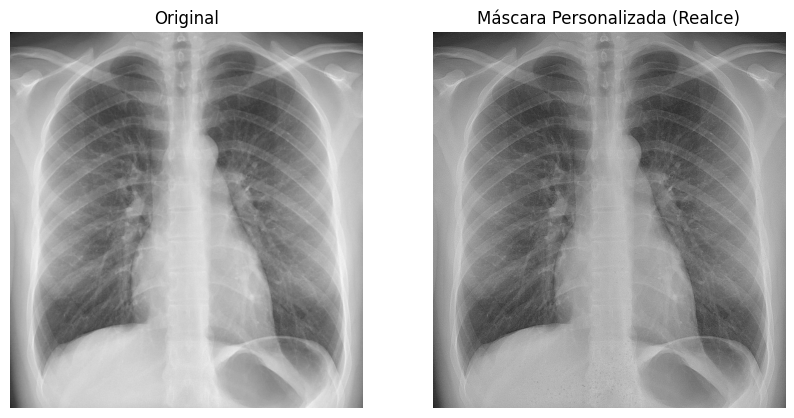

In [8]:
# Comparación con imagen original
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_custom, cmap='gray')
plt.title('Máscara Personalizada (Realce)')
plt.axis('off')

plt.show()